# Sales Performance Dashboard

## Project Overview

This notebook builds an executive-style **Sales Performance Dashboard** from a retail sales dataset.

The analysis combines:

- data cleaning
- KPI calculation
- monthly trend analysis
- regional performance
- category revenue and profit
- product ranking
- profitability diagnostics
- dashboard generation
- executive interpretation

### Actual Dataset Summary

- **Rows:** 200
- **Columns:** 14
- **Date range:** 2023-01-01 to 2023-07-19
- **Revenue:** $1,074,116
- **Profit:** $93,264
- **Profit Margin:** 8.7%
- **Units Sold:** 18,153

The dashboard is designed to answer:

> Where is sales performance strong, and where is revenue hiding profitability problems?

# Part 1 — Import Libraries

## 1. Load Python Packages

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from IPython.display import display

pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.2f}"
)

# Part 2 — Set File Paths

## 2. Make the Notebook Portable

The original script used a hard-coded Windows Downloads path.

This GitHub version searches for the CSV in the project root or a `data/` folder.

In [2]:
candidate_files = [
    Path("Assignment 2_abasiaka  Anwanakak.csv"),
    Path("sample_sales_data.csv"),
    Path("sales_data.csv"),
    Path("data/Assignment 2_abasiaka  Anwanakak.csv"),
    Path("data/sample_sales_data.csv"),
    Path("data/sales_data.csv"),
]

DATA_FILE = next(
    (
        path
        for path in candidate_files
        if path.exists()
    ),
    None,
)

OUTPUT_DIR = Path(
    "sales_dashboard_outputs"
)
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

if DATA_FILE is None:
    raise FileNotFoundError(
        "Sales dataset not found. "
        "Place the CSV beside the notebook "
        "or inside the data/ folder."
    )

print("Dataset:", DATA_FILE.resolve())
print("Output folder:", OUTPUT_DIR.resolve())

Dataset: C:\Users\tooko\Downloads\Assignment 2_abasiaka  Anwanakak.csv
Output folder: C:\Users\tooko\Downloads\sales_dashboard_outputs


# Part 3 — Load and Inspect the Dataset

## 3. Load the Sales Data

In [3]:
df_raw = pd.read_csv(
    DATA_FILE
)

print(
    f"Rows: {df_raw.shape[0]:,}"
)
print(
    f"Columns: {df_raw.shape[1]}"
)

display(
    df_raw.head()
)

Rows: 200
Columns: 14


,order_id,order_date,region,channel,product_category,product,units_sold,unit_price,discount_pct,cogs,customer_segment,revenue,profit,month
0,ORD1000,2023-01-01,West,Wholesale,Electronics,Product_0,60,94,9,55,Corporate,"1,964.60",754.60,2023-01
1,ORD1001,2023-01-02,North,Wholesale,Home Appliances,Product_1,66,87,4,33,Small Business,"1,131.00",702.00,2023-01
2,ORD1002,2023-01-03,East,Online,Sports,Product_2,120,466,3,300,Corporate,"8,854.00","3,154.00",2023-01
3,ORD1003,2023-01-04,West,Online,Sports,Product_3,87,375,0,301,Small Business,"17,456.25","2,707.25",2023-01
4,ORD1004,2023-01-05,East,Retail,Home Appliances,Product_4,105,10,0,218,Consumer,306.00,"-7,542.00",2023-01


## 4. Review Dataset Structure

The dataset includes order, product, region, channel, pricing, cost, revenue, profit, customer segment, and unit-volume fields.

In [4]:
structure = pd.DataFrame({
    "Data_Type": df_raw.dtypes,
    "Missing_Values": df_raw.isna().sum(),
    "Unique_Values": df_raw.nunique(),
})

display(structure)

,Data_Type,Missing_Values,Unique_Values
order_id,str,0,200
order_date,str,0,200
region,str,0,4
channel,str,0,3
product_category,str,0,5
product,str,0,200
units_sold,int64,0,71
unit_price,int64,0,161
discount_pct,int64,0,15
cogs,int64,0,154


## 5. Check Data Quality

Review:

- exact duplicate rows
- missing values
- invalid dates

The uploaded dataset contains no exact duplicates and no missing values.

In [5]:
quality_checks = pd.DataFrame({
    "Check": [
        "Rows",
        "Columns",
        "Exact duplicate rows",
        "Missing values",
    ],
    "Result": [
        len(df_raw),
        df_raw.shape[1],
        int(
            df_raw.duplicated().sum()
        ),
        int(
            df_raw.isna().sum().sum()
        ),
    ],
})

display(quality_checks)

,Check,Result
0,Rows,200
1,Columns,14
2,Exact duplicate rows,0
3,Missing values,0


# Part 4 — Clean and Prepare the Data

## 6. Remove Exact Duplicates

In [6]:
df = (
    df_raw
    .drop_duplicates()
    .copy()
)

print(
    "Rows retained:",
    f"{len(df):,}"
)

Rows retained: 200


## 7. Convert the Order Date

In [7]:
df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce",
)

invalid_dates = (
    df["order_date"]
    .isna()
    .sum()
)

print(
    "Invalid dates:",
    invalid_dates
)
print(
    "Earliest order:",
    df["order_date"].min().date()
)
print(
    "Latest order:",
    df["order_date"].max().date()
)

Invalid dates: 0
Earliest order: 2023-01-01
Latest order: 2023-07-19


## 8. Create the Month Field

In [8]:
df["month"] = (
    df["order_date"]
    .dt.to_period("M")
    .astype(str)
)

display(
    df[
        [
            "order_date",
            "month",
        ]
    ].head()
)

,order_date,month
0,2023-01-01,2023-01
1,2023-01-02,2023-01
2,2023-01-03,2023-01
3,2023-01-04,2023-01
4,2023-01-05,2023-01


## 9. Confirm Numeric Business Measures

The source revenue and profit fields are used as provided.

In [9]:
numeric_columns = [
    "units_sold",
    "unit_price",
    "discount_pct",
    "cogs",
    "revenue",
    "profit",
]

for column in numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce",
        )

display(
    df[numeric_columns]
    .dtypes
    .to_frame("Data_Type")
)

,Data_Type
units_sold,int64
unit_price,int64
discount_pct,int64
cogs,int64
revenue,float64
profit,float64


# Part 5 — Add a Region Filter

## 10. Select a Region

Use `"All"` for the full business view or replace it with `East`, `West`, `North`, or `South`.

In [10]:
SELECTED_REGION = "All"

analysis_df = df.copy()

if SELECTED_REGION != "All":
    analysis_df = analysis_df[
        analysis_df["region"]
        == SELECTED_REGION
    ].copy()

print(
    "Selected region:",
    SELECTED_REGION
)
print(
    "Rows in analysis:",
    f"{len(analysis_df):,}"
)

Selected region: All
Rows in analysis: 200


# Part 6 — Calculate Executive KPIs

## 11. Revenue, Profit, Margin, and Units Sold

In [11]:
ytd_revenue = (
    analysis_df["revenue"].sum()
)

ytd_profit = (
    analysis_df["profit"].sum()
)

ytd_margin = (
    ytd_profit / ytd_revenue
    if ytd_revenue != 0
    else np.nan
)

ytd_units = (
    analysis_df["units_sold"].sum()
)

kpi_table = pd.DataFrame({
    "KPI": [
        "Revenue",
        "Profit",
        "Profit Margin",
        "Units Sold",
    ],
    "Value": [
        f"${ytd_revenue:,.0f}",
        f"${ytd_profit:,.0f}",
        f"{ytd_margin:.1%}",
        f"{ytd_units:,.0f}",
    ],
})

display(kpi_table)

,KPI,Value
0,Revenue,"$1,074,116"
1,Profit,"$93,264"
2,Profit Margin,8.7%
3,Units Sold,"18,153"


# Part 7 — Build Summary Tables

## 12. Monthly Performance

In [12]:
monthly_summary = (
    analysis_df
    .groupby("month")
    .agg(
        Revenue=("revenue", "sum"),
        Profit=("profit", "sum"),
        Units_Sold=("units_sold", "sum"),
    )
    .reset_index()
)

monthly_summary[
    "Profit_Margin"
] = (
    monthly_summary["Profit"]
    / monthly_summary["Revenue"]
)

display(
    monthly_summary.round(2)
)

,month,Revenue,Profit,Units_Sold,Profit_Margin
0,2023-01,"190,452.15","43,900.15",2771,0.23
1,2023-02,"165,263.15","35,437.15",2385,0.21
2,2023-03,"176,468.20","30,198.20",2872,0.17
3,2023-04,"199,424.00","-5,567.00",2883,-0.03
4,2023-05,"130,311.30","4,438.30",2883,0.03
5,2023-06,"135,511.35","-27,850.65",2602,-0.21
6,2023-07,"76,685.40","12,707.40",1757,0.17


## 13. Regional Performance

In [13]:
region_summary = (
    analysis_df
    .groupby("region")
    .agg(
        Revenue=("revenue", "sum"),
        Profit=("profit", "sum"),
        Units_Sold=("units_sold", "sum"),
    )
    .sort_values(
        "Revenue",
        ascending=False,
    )
    .reset_index()
)

region_summary[
    "Profit_Margin"
] = (
    region_summary["Profit"]
    / region_summary["Revenue"]
)

display(
    region_summary.round(2)
)

,region,Revenue,Profit,Units_Sold,Profit_Margin
0,East,"313,513.20","40,124.20",4789,0.13
1,West,"304,807.75","37,927.75",4865,0.12
2,North,"261,163.10","31,430.10",4184,0.12
3,South,"194,631.50","-16,218.50",4315,-0.08


## 14. Category Performance

In [14]:
category_summary = (
    analysis_df
    .groupby("product_category")
    .agg(
        Revenue=("revenue", "sum"),
        Profit=("profit", "sum"),
        Units_Sold=("units_sold", "sum"),
    )
    .sort_values(
        "Revenue",
        ascending=False,
    )
    .reset_index()
)

category_summary[
    "Profit_Margin"
] = (
    category_summary["Profit"]
    / category_summary["Revenue"]
)

display(
    category_summary.round(2)
)

,product_category,Revenue,Profit,Units_Sold,Profit_Margin
0,Sports,"292,086.75","113,044.75",4102,0.39
1,Home Appliances,"227,053.10","-11,093.90",3304,-0.05
2,Furniture,"215,023.30","-8,910.70",4463,-0.04
3,Electronics,"210,157.50","5,068.50",3925,0.02
4,Clothing,"129,794.90","-4,845.10",2359,-0.04


## 15. Product Performance

In [15]:
product_summary = (
    analysis_df
    .groupby("product")
    .agg(
        Revenue=("revenue", "sum"),
        Profit=("profit", "sum"),
        Units_Sold=("units_sold", "sum"),
    )
    .sort_values(
        "Revenue",
        ascending=False,
    )
    .reset_index()
)

display(
    product_summary.head(10)
)

,product,Revenue,Profit,Units_Sold
0,Product_66,"20,947.50","6,052.50",62
1,Product_49,"18,102.00","15,288.00",63
2,Product_3,"17,456.25","2,707.25",87
3,Product_32,"17,045.00","3,220.00",66
4,Product_60,"16,983.00","11,493.00",56
5,Product_176,"16,451.75","9,983.75",61
6,Product_22,"16,092.00","11,736.00",83
7,Product_28,"16,075.80","12,409.80",63
8,Product_15,"15,940.05","13,167.05",123
9,Product_59,"15,379.20","8,083.20",104


# Part 8 — Key Business Findings

## 16. Executive Insights

### East Leads Revenue, but South Is Loss-Making

East generated approximately **$313,513** in revenue.

South generated approximately **$194,632** in revenue but lost about **$16,219**, producing a **-8.3%** margin.

### Sports Is the Strongest Category

Sports generated:

- **$292,087 revenue**
- **$113,045 profit**
- **38.7% margin**

### April Had the Highest Revenue but Negative Profit

April revenue reached approximately **$199,424**, while profit was **$-5,567**.

### June Was the Largest Profitability Warning

June generated approximately **$135,511** in revenue but lost **$27,851**, for a **-20.6%** margin.

### July Is a Partial Month

The dataset ends on **2023-07-19**.

July revenue should therefore not be compared directly with complete prior months without adjusting for the incomplete period.

### Product Revenue Leaders

- Highest revenue: **Product_66 — $20,948**
- Lowest revenue: **Product_118 — $56**

# Part 9 — Monthly Revenue Trend

## 17. Plot Revenue by Month

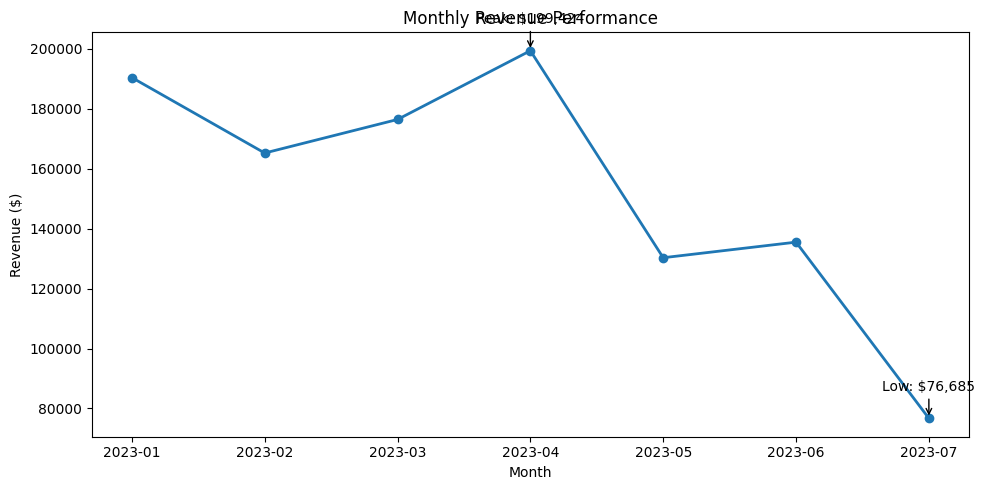

In [16]:
plt.figure(
    figsize=(10, 5)
)

plt.plot(
    monthly_summary["month"],
    monthly_summary["Revenue"],
    marker="o",
    linewidth=2,
)

peak_index = (
    monthly_summary["Revenue"]
    .idxmax()
)

low_index = (
    monthly_summary["Revenue"]
    .idxmin()
)

plt.annotate(
    (
        "Peak: "
        f"${monthly_summary.loc[peak_index, 'Revenue']:,.0f}"
    ),
    xy=(
        peak_index,
        monthly_summary.loc[
            peak_index,
            "Revenue",
        ],
    ),
    xytext=(0, 20),
    textcoords="offset points",
    ha="center",
    arrowprops=dict(
        arrowstyle="->"
    ),
)

plt.annotate(
    (
        "Low: "
        f"${monthly_summary.loc[low_index, 'Revenue']:,.0f}"
    ),
    xy=(
        low_index,
        monthly_summary.loc[
            low_index,
            "Revenue",
        ],
    ),
    xytext=(0, 20),
    textcoords="offset points",
    ha="center",
    arrowprops=dict(
        arrowstyle="->"
    ),
)

plt.title(
    "Monthly Revenue Performance"
)
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()

# Part 10 — Regional Performance

## 18. Revenue by Region

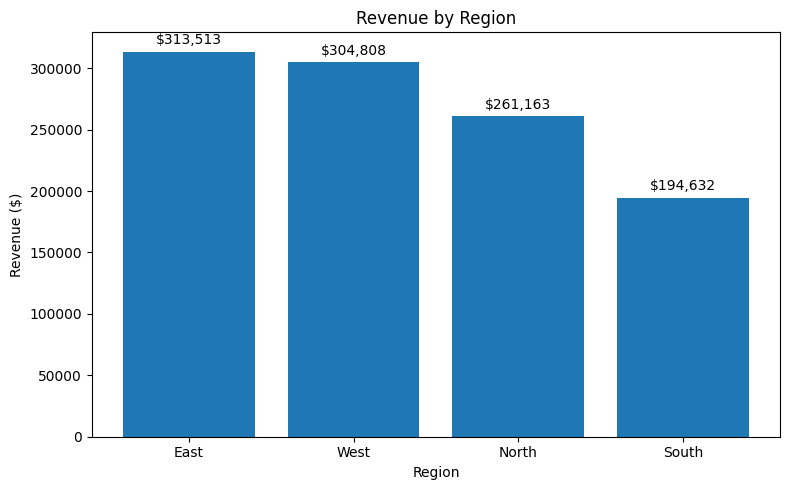

In [17]:
plt.figure(
    figsize=(8, 5)
)

bars = plt.bar(
    region_summary["region"],
    region_summary["Revenue"],
)

plt.bar_label(
    bars,
    labels=[
        f"${value:,.0f}"
        for value
        in region_summary["Revenue"]
    ],
    padding=3,
)

plt.title(
    "Revenue by Region"
)
plt.xlabel("Region")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()

# Part 11 — Category Performance

## 19. Revenue and Profit by Category

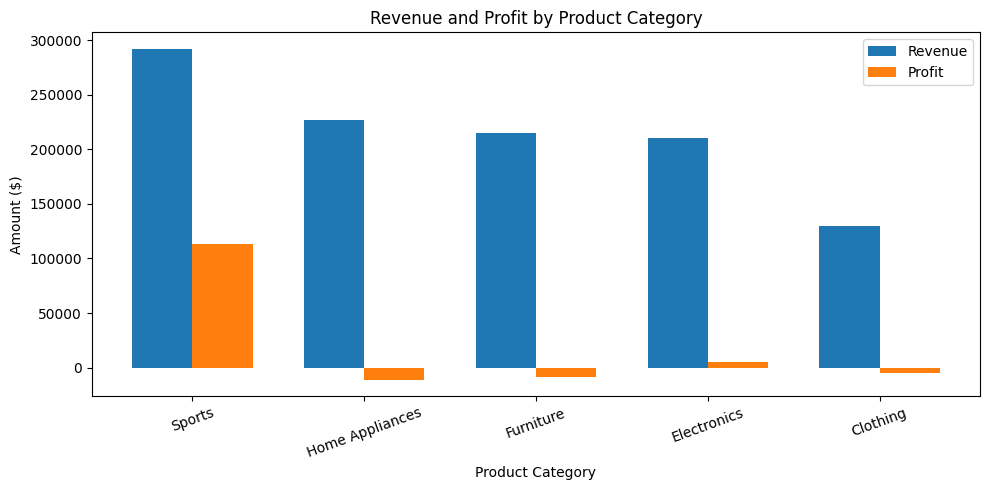

In [18]:
x = np.arange(
    len(category_summary)
)

width = 0.35

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    x - width / 2,
    category_summary["Revenue"],
    width,
    label="Revenue",
)

plt.bar(
    x + width / 2,
    category_summary["Profit"],
    width,
    label="Profit",
)

plt.xticks(
    x,
    category_summary["product_category"],
    rotation=20,
)

plt.title(
    "Revenue and Profit by Product Category"
)
plt.xlabel("Product Category")
plt.ylabel("Amount ($)")
plt.legend()
plt.tight_layout()
plt.show()

## 20. Profit Margin by Category

This view shows which high-revenue categories are actually profitable.

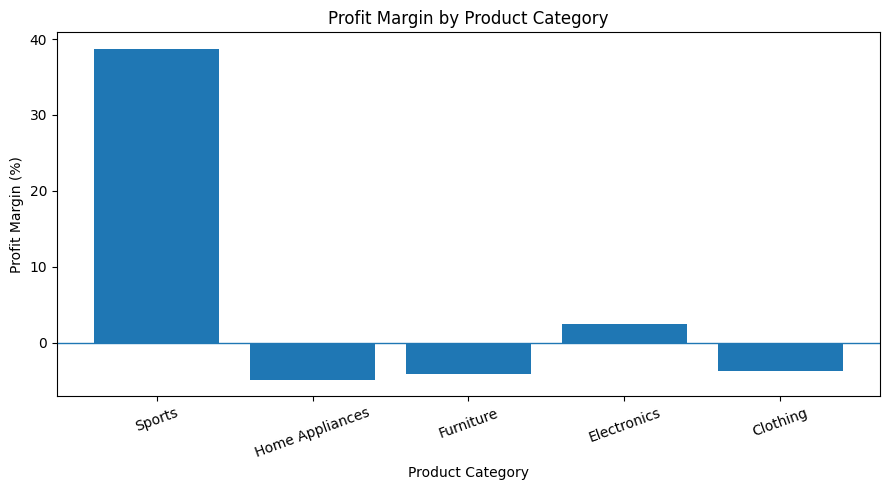

In [19]:
plt.figure(
    figsize=(9, 5)
)

plt.bar(
    category_summary[
        "product_category"
    ],
    category_summary[
        "Profit_Margin"
    ] * 100,
)

plt.axhline(
    0,
    linewidth=1,
)

plt.title(
    "Profit Margin by Product Category"
)
plt.xlabel("Product Category")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Part 12 — Product Rankings

## 21. Top 10 Products by Revenue

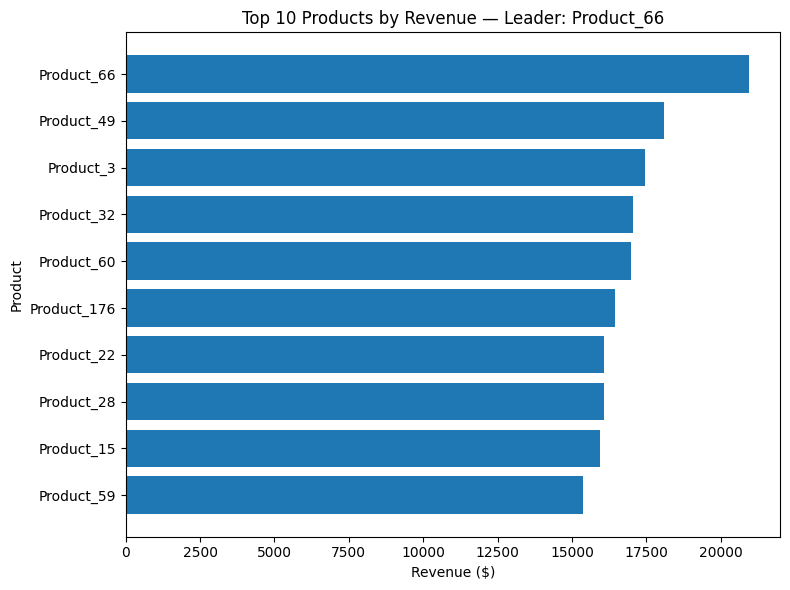

In [20]:
top_10_products = (
    product_summary
    .head(10)
    .sort_values(
        "Revenue",
        ascending=True,
    )
)

plt.figure(
    figsize=(8, 6)
)

plt.barh(
    top_10_products["product"],
    top_10_products["Revenue"],
)

plt.title(
    (
        "Top 10 Products by Revenue — "
        f"Leader: "
        f"{top_10_products.iloc[-1]['product']}"
    )
)
plt.xlabel("Revenue ($)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

## 22. Bottom 10 Products by Revenue

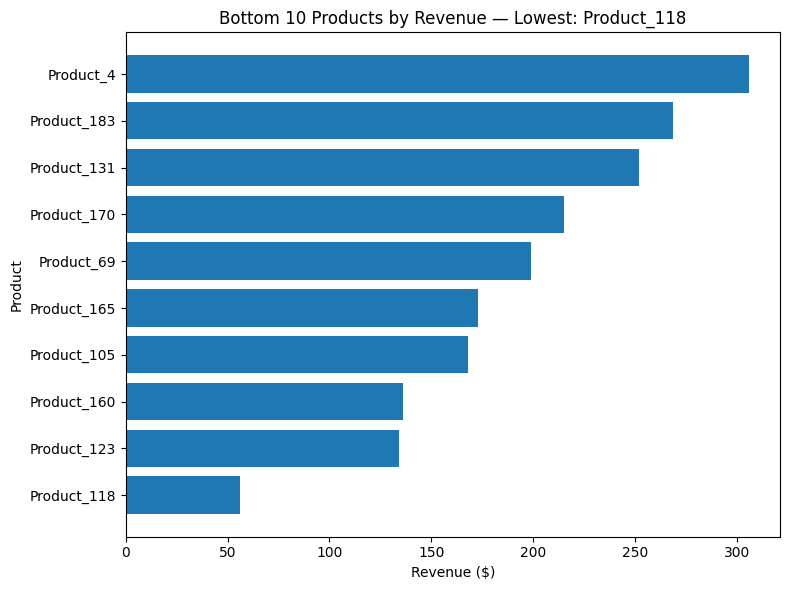

In [21]:
bottom_10_products = (
    product_summary
    .tail(10)
    .sort_values(
        "Revenue",
        ascending=True,
    )
)

plt.figure(
    figsize=(8, 6)
)

plt.barh(
    bottom_10_products["product"],
    bottom_10_products["Revenue"],
)

plt.title(
    (
        "Bottom 10 Products by Revenue — "
        f"Lowest: "
        f"{bottom_10_products.iloc[0]['product']}"
    )
)
plt.xlabel("Revenue ($)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

# Part 13 — Profitability Diagnostics

## 23. Identify Loss-Making Regions and Categories

In [22]:
loss_regions = (
    region_summary[
        region_summary["Profit"] < 0
    ][
        [
            "region",
            "Revenue",
            "Profit",
            "Profit_Margin",
        ]
    ]
)

loss_categories = (
    category_summary[
        category_summary["Profit"] < 0
    ][
        [
            "product_category",
            "Revenue",
            "Profit",
            "Profit_Margin",
        ]
    ]
)

print(
    "Loss-making regions:"
)
display(
    loss_regions.round(2)
)

print(
    "Loss-making categories:"
)
display(
    loss_categories.round(2)
)

Loss-making regions:


,region,Revenue,Profit,Profit_Margin
3,South,"194,631.50","-16,218.50",-0.08


Loss-making categories:


,product_category,Revenue,Profit,Profit_Margin
1,Home Appliances,"227,053.10","-11,093.90",-0.05
2,Furniture,"215,023.30","-8,910.70",-0.04
4,Clothing,"129,794.90","-4,845.10",-0.04


## 24. Identify the Most Profitable and Most Loss-Making Products

In [23]:
most_profitable_products = (
    product_summary
    .sort_values(
        "Profit",
        ascending=False,
    )
    .head(10)
)

largest_loss_products = (
    product_summary
    .sort_values(
        "Profit",
        ascending=True,
    )
    .head(10)
)

print(
    "Most profitable products:"
)
display(
    most_profitable_products
)

print(
    "Largest loss-making products:"
)
display(
    largest_loss_products
)

Most profitable products:


,product,Revenue,Profit,Units_Sold
1,Product_49,"18,102.00","15,288.00",63
8,Product_15,"15,940.05","13,167.05",123
7,Product_28,"16,075.80","12,409.80",63
12,Product_25,"14,375.40","11,762.40",99
6,Product_22,"16,092.00","11,736.00",83
4,Product_60,"16,983.00","11,493.00",56
20,Product_80,"12,204.00","11,169.00",100
22,Product_35,"11,769.10","10,866.10",94
5,Product_176,"16,451.75","9,983.75",61
34,Product_149,"10,118.40","9,830.40",124


Largest loss-making products:


,product,Revenue,Profit,Units_Sold
120,Product_168,"2,749.50","-14,546.50",62
167,Product_179,742.90,"-11,973.10",74
138,Product_150,"1,790.75","-9,490.25",99
143,Product_18,"1,680.00","-9,275.00",77
109,Product_55,"3,365.15","-9,251.85",110
105,Product_73,"3,510.00","-9,048.00",71
140,Product_84,"1,747.20","-8,752.80",73
163,Product_137,963.20,"-8,388.80",117
192,Product_131,252.00,"-8,316.00",120
190,Product_4,306.00,"-7,542.00",105


# Part 14 — Build the Full Executive Dashboard

## 25. Generate the Dashboard

This version fixes the KPI helper logic from the original script so each KPI card uses an already-created axis directly.

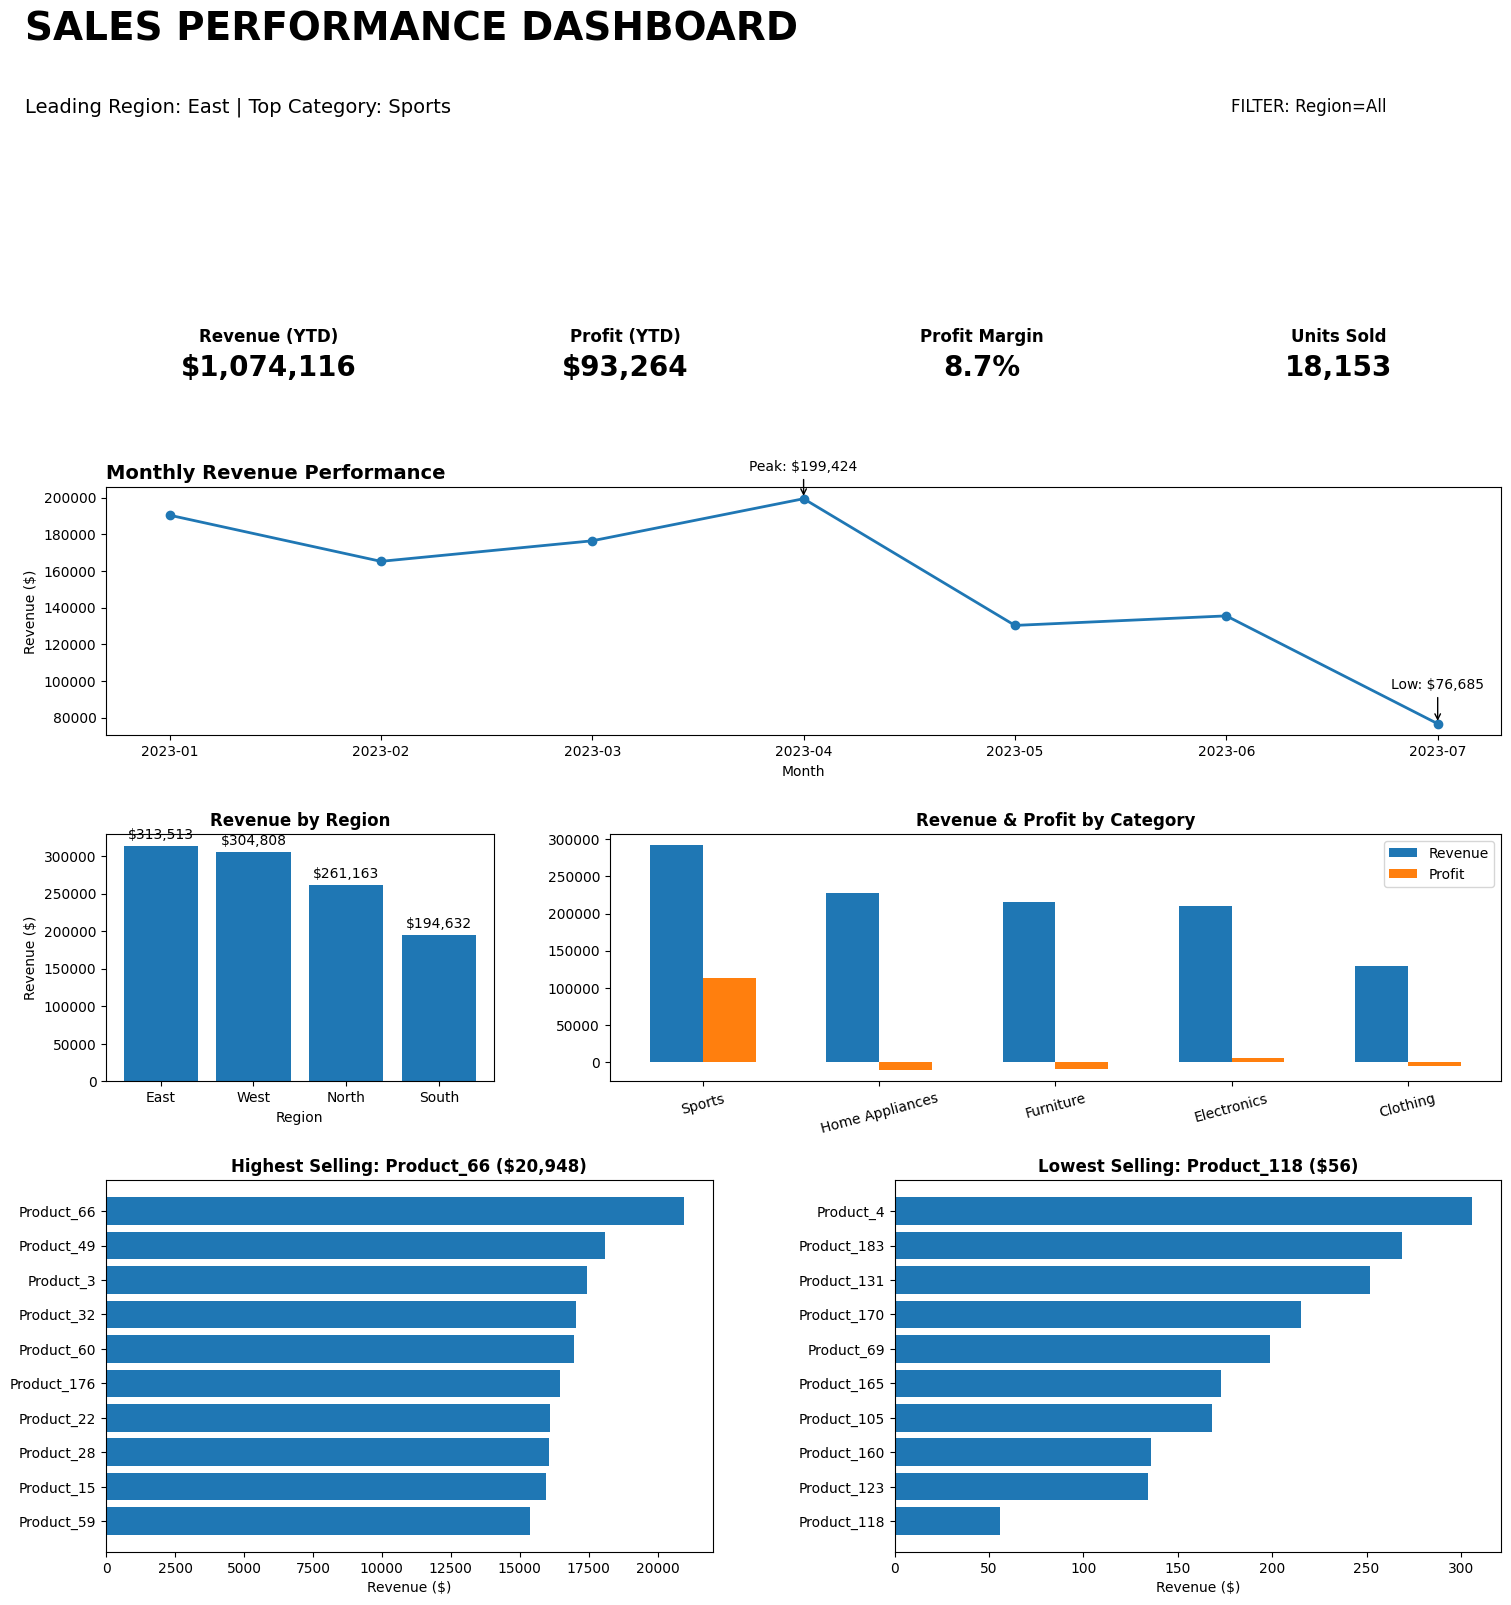

Dashboard saved to: sales_dashboard_outputs\sales_performance_dashboard.png


In [24]:
top_region_name = (
    region_summary.iloc[0]["region"]
)

top_category_name = (
    category_summary
    .iloc[0]["product_category"]
)

fig = plt.figure(
    figsize=(18, 18)
)

grid = gridspec.GridSpec(
    5,
    3,
    height_ratios=[
        0.5,
        0.5,
        2,
        2,
        3,
    ],
    wspace=0.30,
    hspace=0.50,
)

fig.text(
    0.08,
    0.95,
    "SALES PERFORMANCE DASHBOARD",
    fontsize=28,
    fontweight="bold",
)

fig.text(
    0.08,
    0.91,
    (
        f"Leading Region: "
        f"{top_region_name} | "
        f"Top Category: "
        f"{top_category_name}"
    ),
    fontsize=14,
)

fig.text(
    0.75,
    0.91,
    f"FILTER: Region={SELECTED_REGION}",
    fontsize=12,
)

def draw_kpi_card(
    axis,
    label,
    value,
):
    axis.text(
        0.5,
        0.75,
        label,
        fontsize=12,
        ha="center",
        fontweight="bold",
    )

    axis.text(
        0.5,
        0.20,
        value,
        fontsize=20,
        ha="center",
        fontweight="bold",
    )

    axis.set_xticks([])
    axis.set_yticks([])

    for spine in axis.spines.values():
        spine.set_visible(False)


kpi_grid = (
    gridspec
    .GridSpecFromSubplotSpec(
        1,
        4,
        subplot_spec=grid[1, :],
        wspace=0.10,
    )
)

kpi_axes = [
    fig.add_subplot(
        kpi_grid[0, index]
    )
    for index in range(4)
]

draw_kpi_card(
    kpi_axes[0],
    "Revenue (YTD)",
    f"${ytd_revenue:,.0f}",
)

draw_kpi_card(
    kpi_axes[1],
    "Profit (YTD)",
    f"${ytd_profit:,.0f}",
)

draw_kpi_card(
    kpi_axes[2],
    "Profit Margin",
    f"{ytd_margin:.1%}",
)

draw_kpi_card(
    kpi_axes[3],
    "Units Sold",
    f"{ytd_units:,.0f}",
)

ax_trend = fig.add_subplot(
    grid[2, :]
)

ax_trend.plot(
    monthly_summary["month"],
    monthly_summary["Revenue"],
    marker="o",
    linewidth=2,
)

ax_trend.set_title(
    "Monthly Revenue Performance",
    fontsize=14,
    fontweight="bold",
    loc="left",
)

ax_trend.set_xlabel("Month")
ax_trend.set_ylabel("Revenue ($)")

peak_idx = (
    monthly_summary["Revenue"]
    .idxmax()
)

low_idx = (
    monthly_summary["Revenue"]
    .idxmin()
)

ax_trend.annotate(
    (
        "Peak: "
        f"${monthly_summary.loc[peak_idx, 'Revenue']:,.0f}"
    ),
    xy=(
        peak_idx,
        monthly_summary.loc[
            peak_idx,
            "Revenue",
        ],
    ),
    xytext=(0, 20),
    textcoords="offset points",
    ha="center",
    arrowprops=dict(
        arrowstyle="->"
    ),
)

ax_trend.annotate(
    (
        "Low: "
        f"${monthly_summary.loc[low_idx, 'Revenue']:,.0f}"
    ),
    xy=(
        low_idx,
        monthly_summary.loc[
            low_idx,
            "Revenue",
        ],
    ),
    xytext=(0, 25),
    textcoords="offset points",
    ha="center",
    arrowprops=dict(
        arrowstyle="->"
    ),
)

ax_region = fig.add_subplot(
    grid[3, 0]
)

region_bars = ax_region.bar(
    region_summary["region"],
    region_summary["Revenue"],
)

ax_region.bar_label(
    region_bars,
    labels=[
        f"${value:,.0f}"
        for value
        in region_summary["Revenue"]
    ],
    padding=3,
)

ax_region.set_title(
    "Revenue by Region",
    fontweight="bold",
)

ax_region.set_xlabel("Region")
ax_region.set_ylabel("Revenue ($)")

ax_category = fig.add_subplot(
    grid[3, 1:]
)

category_x = np.arange(
    len(category_summary)
)

category_width = 0.30

ax_category.bar(
    category_x - 0.15,
    category_summary["Revenue"],
    category_width,
    label="Revenue",
)

ax_category.bar(
    category_x + 0.15,
    category_summary["Profit"],
    category_width,
    label="Profit",
)

ax_category.set_title(
    "Revenue & Profit by Category",
    fontweight="bold",
)

ax_category.set_xticks(
    category_x
)

ax_category.set_xticklabels(
    category_summary[
        "product_category"
    ],
    rotation=15,
)

ax_category.legend()

product_grid = (
    gridspec
    .GridSpecFromSubplotSpec(
        1,
        2,
        subplot_spec=grid[4, :],
        wspace=0.30,
    )
)

ax_top = fig.add_subplot(
    product_grid[0, 0]
)

ax_top.barh(
    top_10_products["product"],
    top_10_products["Revenue"],
)

ax_top.set_title(
    (
        "Highest Selling: "
        f"{top_10_products.iloc[-1]['product']} "
        f"(${top_10_products.iloc[-1]['Revenue']:,.0f})"
    ),
    fontweight="bold",
)

ax_top.set_xlabel(
    "Revenue ($)"
)

ax_bottom = fig.add_subplot(
    product_grid[0, 1]
)

ax_bottom.barh(
    bottom_10_products["product"],
    bottom_10_products["Revenue"],
)

ax_bottom.set_title(
    (
        "Lowest Selling: "
        f"{bottom_10_products.iloc[0]['product']} "
        f"(${bottom_10_products.iloc[0]['Revenue']:,.0f})"
    ),
    fontweight="bold",
)

ax_bottom.set_xlabel(
    "Revenue ($)"
)

dashboard_path = (
    OUTPUT_DIR
    / "sales_performance_dashboard.png"
)

plt.savefig(
    dashboard_path,
    bbox_inches="tight",
    dpi=300,
)

plt.show()

print(
    "Dashboard saved to:",
    dashboard_path
)

# Part 15 — Generate an Executive Summary

## 26. Print Key Findings

In [25]:
peak_row = monthly_summary.loc[
    monthly_summary["Revenue"].idxmax()
]

low_row = monthly_summary.loc[
    monthly_summary["Revenue"].idxmin()
]

top_product_row = (
    product_summary.iloc[0]
)

bottom_product_row = (
    product_summary.iloc[-1]
)

print("=" * 60)
print(
    "EXECUTIVE SALES SUMMARY"
)
print("=" * 60)

print(
    f"Revenue: ${ytd_revenue:,.0f}"
)
print(
    f"Profit: ${ytd_profit:,.0f}"
)
print(
    f"Profit Margin: {ytd_margin:.1%}"
)
print(
    f"Units Sold: {ytd_units:,.0f}"
)
print(
    f"Leading Region: {top_region_name}"
)
print(
    f"Top Category: {top_category_name}"
)
print(
    (
        "Peak Revenue Month: "
        f"{peak_row['month']} "
        f"(${peak_row['Revenue']:,.0f})"
    )
)
print(
    (
        "Lowest Revenue Month: "
        f"{low_row['month']} "
        f"(${low_row['Revenue']:,.0f})"
    )
)
print(
    (
        "Highest-Revenue Product: "
        f"{top_product_row['product']} "
        f"(${top_product_row['Revenue']:,.0f})"
    )
)
print(
    (
        "Lowest-Revenue Product: "
        f"{bottom_product_row['product']} "
        f"(${bottom_product_row['Revenue']:,.0f})"
    )
)

EXECUTIVE SALES SUMMARY
Revenue: $1,074,116
Profit: $93,264
Profit Margin: 8.7%
Units Sold: 18,153
Leading Region: East
Top Category: Sports
Peak Revenue Month: 2023-04 ($199,424)
Lowest Revenue Month: 2023-07 ($76,685)
Highest-Revenue Product: Product_66 ($20,948)
Lowest-Revenue Product: Product_118 ($56)


# Part 16 — Interpretation Notes

## 27. Limitations

### July Is Incomplete

The dataset ends on July 19, 2023.

July should not be compared directly with complete prior months without adjusting for partial-month coverage.

### Revenue Is Not Profit

April is the highest-revenue month but generated a loss.

South and several categories also generate meaningful sales while losing money.

### Source Revenue and Profit Fields Are Used as Provided

No alternative accounting formula is imposed.

# Part 17 — Export Analytical Tables

## 28. Save Summary Tables

In [26]:
monthly_summary.to_csv(
    OUTPUT_DIR
    / "monthly_performance.csv",
    index=False,
)

region_summary.to_csv(
    OUTPUT_DIR
    / "regional_performance.csv",
    index=False,
)

category_summary.to_csv(
    OUTPUT_DIR
    / "category_performance.csv",
    index=False,
)

product_summary.to_csv(
    OUTPUT_DIR
    / "product_performance.csv",
    index=False,
)

print(
    "Summary tables saved to:",
    OUTPUT_DIR.resolve()
)

Summary tables saved to: C:\Users\tooko\Downloads\sales_dashboard_outputs


# Final Takeaway

The dashboard shows strong topline sales, but the deeper analysis reveals a more important management story:

- East leads regional revenue.
- Sports is the strongest category by revenue and profit.
- South is loss-making despite meaningful sales.
- April had the highest revenue but negative profit.
- June produced the largest monthly loss.
- July is only a partial month.
- Product rankings should be considered alongside profitability.

> **Sales growth is only valuable when it translates into sustainable profit.**